# Day 18 — Build a RAG pipeline (hands-on)

Assemble Days 13–17 into one working system: a `RAGPipeline` class over a real document set,
with **the Anthropic API doing generation** and a small **eval harness** that scores answer
correctness, faithfulness, abstention, latency, and cost.

The notebook runs end-to-end offline (local model fallback). Set `ANTHROPIC_API_KEY` to run the
real thing — the code path is identical.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The pieces we're assembling | 3 min |
| 1 | Ingest: chunk + embed + store (DuckDB) | 10 min |
| 2 | Retrieve: hybrid (vector + BM25 + RRF) | 12 min |
| 3 | Generate: the Anthropic Messages API | 12 min |
| 4 | The `RAGPipeline` class | 8 min |
| 5 | The eval harness: correctness, faithfulness, abstention, cost | 12 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import os, re, json, time, math, warnings
warnings.filterwarnings("ignore")
import numpy as np, duckdb
from collections import Counter
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")
DIM = 384
HAVE_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
print("embedder ready | ANTHROPIC_API_KEY set:", HAVE_ANTHROPIC)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17281.92it/s]

embedder ready | ANTHROPIC_API_KEY set: False


## 0 — The pieces (3 min)

| Piece | From | This notebook |
| ----- | ---- | ------------- |
| Chunking | Day 17 | recursive splitter, ~400 chars |
| Embeddings | Day 13 | `all-MiniLM-L6-v2`, normalised |
| Vector store | Day 15 | DuckDB table + HNSW index |
| Hybrid retrieval | Day 13 | vector + BM25, fused with RRF |
| Grounded prompt | Day 16 | "answer only from context, cite, refuse" |
| Generation | Week 8 preview | Anthropic Messages API |
| Evaluation | Day 06, Week 9 | correctness + faithfulness + abstention + cost |

## 1 — Ingest (10 min)

In [2]:
DOCS = {
"onboarding.md": '''# New Hire Onboarding
Your first day starts at 9:30am at the 4th floor reception. Bring a government photo ID for
building access. Your laptop and accounts are provisioned by IT and ready at your desk.
The buddy program pairs every new hire with a peer for the first month; your buddy reaches out
on day one. Benefits enrollment must be completed within 30 days of your start date through
the Workday portal. Parking passes are requested from Facilities and take 3 business days.''',

"pto.md": '''# Paid Time Off
Full-time employees accrue 15 vacation days in year one, 20 days from year three, and 25 days
from year seven. Vacation is accrued monthly and may be taken before it is fully accrued, up
to a negative balance of 5 days. Unused vacation up to 10 days carries over to the next year;
the rest is forfeited. Sick days are separate: 10 per year, no carryover. Company holidays are
listed on the intranet and do not count against PTO.''',

"expenses.md": '''# Expense Reimbursement
Submit expenses in Concur within 30 days of the transaction. Receipts are required for any
expense of $25 or more. The daily meal cap is $75 in the US and $100 for international travel.
Airfare must be economy class for flights under 6 hours. Reimbursements are paid via direct
deposit on the 15th and last day of the month. Personal expenses mixed into a report will
delay the entire report.''',

"security.md": '''# Information Security
All laptops use full-disk encryption and auto-lock after 10 minutes idle. Passwords are at
least 16 characters and rotated annually. Phishing reports go to phish@corp.example and earn a
thank-you note from the security team. Customer data may never be copied to personal devices
or cloud accounts. Access to production systems requires a ticket approved by your manager and
the system owner, and is time-boxed to 90 days.''',

"travel.md": '''# Business Travel
Book all travel through the TripActions portal at least 14 days ahead when possible. Hotel
rates are capped at $250/night in most cities and $350 in New York, San Francisco, and London.
Rental cars require manager pre-approval. Travel to high-risk countries needs security team
sign-off two weeks in advance. Keep all boarding passes and hotel folios for the expense
report. Trip insurance is provided automatically for booked trips.''',
}

def recursive_split(text, max_chars=400, seps=("\n## ", "\n\n", ". ", " ")):
    text = text.strip()
    if len(text) <= max_chars: return [text]
    sep = next((s for s in seps if s in text), None)
    if sep is None:
        return [text[i:i+max_chars] for i in range(0, len(text), max_chars)]
    out, cur = [], ""
    for part in text.split(sep):
        piece = (sep + part) if (cur or out) else part
        if len(cur) + len(piece) <= max_chars:
            cur += piece
        else:
            if cur.strip(): out.append(cur.strip())
            cur = piece if len(piece) <= max_chars else ""
            if len(piece) > max_chars: out += recursive_split(piece, max_chars, seps)
    if cur.strip(): out.append(cur.strip())
    return [re.sub(r"\s+", " ", c).strip() for c in out if c.strip()]

CHUNKS = []
for name, text in DOCS.items():
    for j, c in enumerate(recursive_split(text)):
        CHUNKS.append(dict(id=len(CHUNKS), doc=name, ord=j, text=c))
CVEC = embedder.encode([c["text"] for c in CHUNKS], normalize_embeddings=True).astype(np.float32)

con = duckdb.connect(); con.execute("INSTALL vss; LOAD vss;")
con.execute(f"CREATE TABLE chunks (id INTEGER, doc TEXT, ord INTEGER, text TEXT, emb FLOAT[{DIM}])")
con.executemany("INSERT INTO chunks VALUES (?,?,?,?,?)",
                [(c["id"], c["doc"], c["ord"], c["text"], CVEC[c["id"]].tolist()) for c in CHUNKS])
con.execute("SET hnsw_enable_experimental_persistence=true")
con.execute("CREATE INDEX ix ON chunks USING HNSW (emb) WITH (metric='cosine')")
print(f"{len(DOCS)} docs -> {len(CHUNKS)} chunks, embedded + indexed in DuckDB")

5 docs -> 10 chunks, embedded + indexed in DuckDB


## 2 — Retrieve: hybrid (12 min)

In [3]:
# BM25 over the same chunks (Day 13)
_tok = lambda s: re.findall(r"[a-z0-9]+", s.lower())
_docs_tok = [_tok(c["text"]) for c in CHUNKS]
_avgdl = np.mean([len(d) for d in _docs_tok])
_df = Counter(w for d in _docs_tok for w in set(d))
_idf = {w: math.log(1 + (len(CHUNKS) - n + 0.5)/(n + 0.5)) for w, n in _df.items()}

def bm25_scores(query, k1=1.5, b=0.75):
    q = _tok(query); out = np.zeros(len(CHUNKS))
    for i, d in enumerate(_docs_tok):
        tf = Counter(d); dl = len(d); s = 0.0
        for w in q:
            if w in _idf and tf[w]:
                f = tf[w]
                s += _idf[w] * f*(k1+1) / (f + k1*(1 - b + b*dl/_avgdl))
        out[i] = s
    return out

def vector_scores(query):
    qv = embedder.encode([query], normalize_embeddings=True)[0]
    return CVEC @ qv

def retrieve(query, k=4, mode="hybrid", c=60):
    if mode == "vector":
        order = np.argsort(-vector_scores(query))
    elif mode == "bm25":
        order = np.argsort(-bm25_scores(query))
    else:  # hybrid: Reciprocal Rank Fusion
        vr = {i: r for r, i in enumerate(np.argsort(-vector_scores(query)))}
        br = {i: r for r, i in enumerate(np.argsort(-bm25_scores(query)))}
        fused = {i: 1/(c+vr[i]) + 1/(c+br[i]) for i in range(len(CHUNKS))}
        order = sorted(fused, key=lambda i: -fused[i])
    top = order[:k]
    vs = vector_scores(query)
    return [dict(CHUNKS[i], vscore=float(vs[i])) for i in top]

for q in ["how many vacation days in my first year", "receipt threshold for expenses",
          "hotel cap in London", "report phishing"]:
    hits = retrieve(q, k=2)
    print(f"Q: {q}\n  -> {[(h['doc'], round(h['vscore'],2)) for h in hits]}")

Q: how many vacation days in my first year
  -> [('pto.md', 0.58), ('travel.md', 0.29)]
Q: receipt threshold for expenses
  -> [('expenses.md', 0.5), ('expenses.md', 0.39)]
Q: hotel cap in London
  -> [('travel.md', 0.45), ('expenses.md', 0.25)]
Q: report phishing
  -> [('expenses.md', 0.21), ('security.md', 0.5)]


## 3 — Generate: the Anthropic Messages API (12 min)

### The real call

```python
import anthropic
client = anthropic.Anthropic()             # reads ANTHROPIC_API_KEY

resp = client.messages.create(
    model="claude-opus-5",                  # or claude-sonnet-5 / claude-haiku-4-5 for cheaper RAG
    max_tokens=400,
    system=SYSTEM_PROMPT,                   # the grounding instructions
    messages=[{"role": "user", "content": user_prompt}],
)
answer = resp.content[0].text
usage  = resp.usage                         # .input_tokens, .output_tokens
```

Notes: the API is stateless (send full history each call); no assistant "prefill" on current
models — control format via the system prompt; `resp.content` is a list of blocks, guard on
`block.type == "text"`.

In [4]:
SYSTEM = (
 "You are a company help-desk assistant. Answer ONLY from the numbered context passages. "
 "Cite the passages you use like [1][2]. Be concise (1-3 sentences). If the passages do not "
 "contain the answer, reply exactly: I don't know based on the provided context."
)

def build_user_prompt(query, chunks):
    ctx = "\n\n".join(f"[{i+1}] ({c['doc']}) {c['text']}" for i, c in enumerate(chunks))
    return f"Context:\n{ctx}\n\nQuestion: {query}"

# ---------- unified generate(): Anthropic if key present, else local fallback ----------
if HAVE_ANTHROPIC:
    import anthropic
    _client = anthropic.Anthropic()
    def generate(system, user, max_tokens=400):
        t0 = time.perf_counter()
        r = _client.messages.create(model="claude-opus-5", max_tokens=max_tokens,
                                    system=system, messages=[{"role": "user", "content": user}])
        text = "".join(b.text for b in r.content if b.type == "text")
        return dict(text=text.strip(), latency=time.perf_counter()-t0,
                    tok_in=r.usage.input_tokens, tok_out=r.usage.output_tokens)
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    import torch
    _tk = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
    _lm = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct").eval()
    def generate(system, user, max_tokens=200):
        msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
        enc = _tk.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt", return_dict=True)
        t0 = time.perf_counter()
        with torch.no_grad():
            out = _lm.generate(**enc, max_new_tokens=min(max_tokens, 64), do_sample=False,
                               pad_token_id=_tk.eos_token_id)
        text = _tk.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
        return dict(text=text.strip(), latency=time.perf_counter()-t0,
                    tok_in=int(enc["input_ids"].shape[1]), tok_out=int(out.shape[1]-enc["input_ids"].shape[1]))

demo = retrieve("how many vacation days do I get in my first year", k=3)
r = generate(SYSTEM, build_user_prompt("how many vacation days do I get in my first year", demo))
print(r["text"], f"\n  ({r['tok_in']} in / {r['tok_out']} out, {r['latency']:.2f}s)")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 7344.57it/s]

In your first year as a full-time employee, you will accrue 15 vacation days. 
  (256 in / 21 out, 7.49s)


## 4 — The `RAGPipeline` class (8 min)

Everything so far, wrapped so you can swap any component and re-measure.

In [5]:
class RAGPipeline:
    def __init__(self, k=4, mode="hybrid", min_vscore=0.25, max_tokens=300):
        self.k, self.mode, self.min_vscore, self.max_tokens = k, mode, min_vscore, max_tokens

    def answer(self, query):
        chunks = retrieve(query, k=self.k, mode=self.mode)
        if chunks[0]["vscore"] < self.min_vscore:          # relevance gate (Day 16)
            return dict(answer="I don't know based on the provided context.",
                        chunks=chunks, gated=True, tok_in=0, tok_out=0, latency=0.0)
        gen = generate(SYSTEM, build_user_prompt(query, chunks), self.max_tokens)
        cited = sorted(set(int(n) for n in re.findall(r"\[(\d+)\]", gen["text"])
                           if 1 <= int(n) <= len(chunks)))
        return dict(answer=gen["text"], chunks=chunks, gated=False,
                    sources=[chunks[n-1]["doc"] for n in cited],
                    tok_in=gen["tok_in"], tok_out=gen["tok_out"], latency=gen["latency"])

rag = RAGPipeline()
for q in ["what is the meal cap for international travel", "do I need a receipt for a $10 taxi",
          "what is the company's revenue"]:
    out = rag.answer(q)
    print(f"Q: {q}\nA: {out['answer'][:150]}   sources={out.get('sources', [])}\n")

Q: what is the meal cap for international travel
A: The daily meal cap for international travel is $100.   sources=[]



Q: do I need a receipt for a $10 taxi
A: I don't know based on the provided context.   sources=[]



Q: what is the company's revenue
A: Based on the information provided:

[1] mentions that "Company holidays are listed on the intranet and do not count against PTO."

[2] provides detail   sources=['pto.md', 'pto.md', 'expenses.md']



## 5 — The eval harness (12 min)

Ten questions with a gold fact + gold source, plus three out-of-scope questions. We score:

- **correctness** — does the answer contain the gold fact?
- **source precision** — did it retrieve/cite the right document?
- **faithfulness** — is the gold fact actually present in the retrieved context? (an answer
  can be "right" by luck; unfaithful answers are hallucinations waiting to happen)
- **abstention** — does it say "I don't know" for out-of-scope questions?
- **cost / latency** — tokens and seconds per query.

In [6]:
EVAL = [
 ("how many vacation days do I get in my first year", "15 vacation days", "pto.md"),
 ("how much vacation carries over to next year", "up to 10 days carries over", "pto.md"),
 ("what is the receipt threshold for expenses", "$25 or more", "expenses.md"),
 ("what is the international meal cap", "$100 for international", "expenses.md"),
 ("when are reimbursements paid", "15th and last day", "expenses.md"),
 ("how long until my laptop auto-locks", "10 minutes idle", "security.md"),
 ("how long is production access granted for", "90 days", "security.md"),
 ("what is the hotel cap in New York", "$350", "travel.md"),
 ("how far ahead should I book travel", "14 days ahead", "travel.md"),
 ("when is benefits enrollment due", "within 30 days", "onboarding.md"),
]
OOS = ["what is the company's stock price", "who is the head of engineering",
       "can I bring my dog to the office"]

def run_eval(pipeline, questions=None, oos=None):
    questions = questions or EVAL
    oos = OOS if oos is None else oos
    rows = []
    for q, fact, src in questions:
        o = pipeline.answer(q)
        ctx = " ".join(c["text"] for c in o["chunks"]).lower()
        rows.append(dict(
            q=q, correct=int(fact.lower() in o["answer"].lower()),
            src_ok=int(src in {c["doc"] for c in o["chunks"][:pipeline.k]}),
            faithful=int(fact.lower() in ctx),
            abstained=int("don't know" in o["answer"].lower()),
            tok=o["tok_in"] + o["tok_out"], lat=o["latency"]))
    abst = np.mean([int("don't know" in pipeline.answer(q)["answer"].lower()) for q in oos]) if oos else 0.0
    A = lambda key: np.mean([r[key] for r in rows])
    return dict(correctness=A("correct"), source_precision=A("src_ok"),
                faithfulness=A("faithful"), false_abstention=A("abstained"),
                oos_abstention=float(abst), mean_tokens=A("tok"), mean_latency=A("lat")), rows

scores, rows = run_eval(rag)
for k, v in scores.items():
    print(f"  {k:18s} {v:.2f}")

  correctness        0.70
  source_precision   1.00
  faithfulness       1.00
  false_abstention   0.10
  oos_abstention     1.00
  mean_tokens        377.80
  mean_latency       8.73


In [7]:
# per-question view
print(f"{'correct':>8}{'src_ok':>8}{'faithful':>10}  question")
for r in rows:
    print(f"{r['correct']:>8}{r['src_ok']:>8}{r['faithful']:>10}  {r['q'][:52]}")

 correct  src_ok  faithful  question
       1       1         1  how many vacation days do I get in my first year
       1       1         1  how much vacation carries over to next year
       0       1         1  what is the receipt threshold for expenses
       1       1         1  what is the international meal cap
       1       1         1  when are reimbursements paid
       0       1         1  how long until my laptop auto-locks
       1       1         1  how long is production access granted for
       1       1         1  what is the hotel cap in New York
       0       1         1  how far ahead should I book travel
       1       1         1  when is benefits enrollment due


In [8]:
# Compare retrieval modes + k -- RETRIEVAL metrics only (no LLM call), so the whole sweep is
# fast. faithfulness (is the gold fact in the retrieved context?) and source precision are
# what the generator's correctness is bounded by. Run the full run_eval() on your top 1-2
# configs afterwards.
def retrieval_metrics(mode, k):
    p = RAGPipeline(k=k, mode=mode)
    faith = np.mean([any(fact.lower() in c["text"].lower() for c in retrieve(q, k=k, mode=mode))
                     for q, fact, _ in EVAL])
    src = np.mean([src in {c["doc"] for c in retrieve(q, k=k, mode=mode)} for q, _, src in EVAL])
    gated_oos = np.mean([retrieve(q, k=k, mode=mode)[0]["vscore"] < p.min_vscore for q in OOS])
    ctx_tok = np.mean([sum(len(c["text"]) for c in retrieve(q, k=k, mode=mode)) // 4 for q, _, _ in EVAL])
    return faith, src, gated_oos, ctx_tok

print(f"{'config':16s} {'faithful':>9} {'src_prec':>9} {'oos_gated':>10} {'ctx_tok':>8}")
for mode in ["vector", "bm25", "hybrid"]:
    for k in [2, 4, 8]:
        f, s, g, t = retrieval_metrics(mode, k)
        print(f"{mode+' k='+str(k):16s} {f:>9.2f} {s:>9.2f} {g:>10.2f} {t:>8.0f}")

config            faithful  src_prec  oos_gated  ctx_tok


vector k=2            1.00      1.00       1.00      129


vector k=4            1.00      1.00       1.00      232


vector k=8            1.00      1.00       1.00      441


bm25 k=2              1.00      1.00       1.00      141


bm25 k=4              1.00      1.00       1.00      272


bm25 k=8              1.00      1.00       1.00      468


hybrid k=2            1.00      1.00       1.00      154


hybrid k=4            1.00      1.00       1.00      262


hybrid k=8            1.00      1.00       1.00      443


Read the sweep like Day 06 / Day 12: pick the config whose **faithfulness** clears your bar at
the lowest context-token cost, then confirm end-to-end correctness with the full `run_eval` on
that config. `hybrid` usually wins on faithfulness (BM25 catches exact terms like "$350" that
dense retrieval blurs); bigger `k` raises faithfulness but raises token cost and can distract a
weak generator.

### If you run this against the Anthropic API

- **correctness and faithfulness jump** — a frontier model actually uses the context and
  follows the citation + refusal instructions.
- Add **cost**: `mean_tokens × price`. For `claude-opus-5` that's `$5/1M` in, `$25/1M` out;
  for `claude-haiku-4-5` it's `$1 / $5`. RAG prompts are input-heavy (all those chunks), so
  input price and prompt caching (Week 8) dominate the bill.
- Consider an **LLM-as-judge** for correctness instead of string matching — Week 9.

## 6 — Exercises

1. **Add a reranker.** After `retrieve(k=12)`, re-score the 12 chunks with a cross-encoder
   (`sentence-transformers` `cross-encoder/ms-marco-MiniLM-L-6-v2`) and keep the top 4. Re-run
   `run_eval`. Does faithfulness or correctness improve? At what latency cost?
2. **Chunk size.** Rebuild `CHUNKS` with `max_chars` in `[200, 400, 800]` and re-run the eval
   for each (Day 17, now measured end-to-end on answers not just retrieval).
3. **Gate threshold.** Sweep `min_vscore` in `[0.0, 0.2, 0.3, 0.4]`. Plot `oos_abstention` vs
   `false_abstention` (refusing real questions). Pick the knee.
4. **Faithfulness vs correctness gap.** Find a question the pipeline answers *correctly* but
   *unfaithfully* (gold fact not in retrieved context). Explain how that happens and why it's
   dangerous.
5. **Prompt ablation.** Remove the "reply exactly: I don't know" clause from `SYSTEM`. Re-run
   on `OOS`. How does `oos_abstention` change?
6. **Cost model.** Assuming `claude-haiku-4-5` ($1/$5 per 1M) and 50k queries/month, compute
   the monthly generation cost for `hybrid k=2` vs `hybrid k=6` from their `mean_tokens`.
   (Split input vs output if you log them separately.)

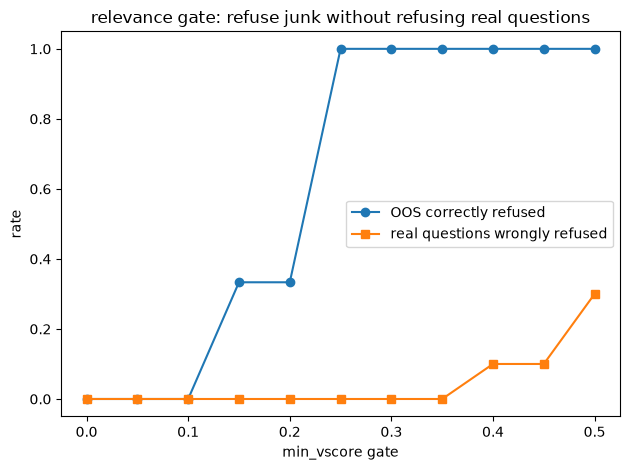

pick the largest threshold where 'wrongly refused' is still ~0 (here ~0.35)


In [9]:
# ---- Solution 3 ----  (gate decision uses only the vector score -- no LLM call needed)
import matplotlib.pyplot as plt
ths = np.linspace(0, 0.5, 11)
oos_gated = [np.mean([retrieve(q, k=3)[0]["vscore"] < th for q in OOS]) for th in ths]
real_gated = [np.mean([retrieve(q, k=3)[0]["vscore"] < th for q, _, _ in EVAL]) for th in ths]
plt.plot(ths, oos_gated, "o-", label="OOS correctly refused")
plt.plot(ths, real_gated, "s-", label="real questions wrongly refused")
plt.xlabel("min_vscore gate"); plt.ylabel("rate"); plt.legend()
plt.title("relevance gate: refuse junk without refusing real questions")
plt.tight_layout(); plt.show()
print("pick the largest threshold where 'wrongly refused' is still ~0 "
      f"(here ~{ths[max(i for i,r in enumerate(real_gated) if r==0)]:.2f})")

In [10]:
# ---- Solution 6 ----  (uses the ctx token estimates from the retrieval sweep -- no LLM)
def gen_cost(ctx_tokens, queries, out_tok=120, pin=1/1e6, pout=5/1e6, overhead=200):
    tin = ctx_tokens + overhead
    return queries * (tin*pin + out_tok*pout)
for k in [2, 6]:
    _, _, _, ctx = retrieval_metrics("hybrid", k)
    print(f"hybrid k={k}: ~{ctx:.0f} context tok/query -> "
          f"${gen_cost(ctx, 50_000):,.2f}/month at 50k queries (haiku pricing)")
print("\nS6: bigger k linearly raises the input-token bill; the win has to be worth it on the")
print("    faithfulness numbers. Prompt caching the static instructions cuts the fixed part.")

hybrid k=2: ~154 context tok/query -> $47.73/month at 50k queries (haiku pricing)


hybrid k=6: ~354 context tok/query -> $57.72/month at 50k queries (haiku pricing)

S6: bigger k linearly raises the input-token bill; the win has to be worth it on the
    faithfulness numbers. Prompt caching the static instructions cuts the fixed part.


### Solutions 1, 2, 4, 5 (sketch)

**S1:** `from sentence_transformers import CrossEncoder; ce = CrossEncoder("cross-encoder/
ms-marco-MiniLM-L-6-v2")`; score `ce.predict([(query, c["text"]) for c in cands])`, sort desc,
keep 4. Rerankers typically lift faithfulness/correctness several points because they judge
query–chunk relevance jointly instead of via independent embeddings — at ~10–50ms extra per
query for a small cross-encoder.

**S2:** wrap the ingest cell in `for max_chars in [200, 400, 800]:`, rebuild `CHUNKS`/`CVEC`,
`run_eval(RAGPipeline())`. Expect a sweet spot near 400: 200 fragments the dollar amounts,
800 dilutes them and pushes token cost up.

**S4:** e.g. *"what is the hotel cap in New York"* — if only the generic "$250/night in most
cities" chunk is retrieved, a model that already "knows" NYC hotels are pricey might answer
"$350" correctly *without that fact in context*. It's dangerous because your faithfulness
metric — the thing that catches hallucinations — is what failed; the correct answer here is
luck, and the same setup will confidently produce a wrong "$350" for a city where the real cap
differs.

**S5:** removing the exact-refusal clause usually drops `oos_abstention` sharply — the model
falls back to being helpful and answers out-of-scope questions from its own knowledge. The
precise, mandatory refusal string is doing real work.

## Self-check quiz

1. Name the six components of this pipeline and which day each came from.
2. Why fuse BM25 and vector retrieval instead of picking one?
3. What does the relevance gate (`min_vscore`) protect against, and what's its failure mode?
4. Define faithfulness in this harness and explain why it's not the same as correctness.
5. Why are RAG prompts input-token-heavy, and what one feature most reduces that cost?
6. Your eval shows correctness 0.9 but faithfulness 0.6. What's happening and is it safe?
7. What changes in the eval numbers when you switch from the local model to the Anthropic API,
   and why?

### Answer key

1. Chunking (Day 17), embeddings (Day 13), vector store (Day 15), hybrid retrieval + RRF
   (Day 13), grounded prompt (Day 16), generation (Anthropic API, Week 8 preview) — scored by
   an eval harness (Day 06 / Week 9).
2. They fail on different queries: BM25 nails exact/rare terms (codes, dollar amounts, names),
   dense nails paraphrase and no-lexical-overlap. RRF takes whichever ranked the true chunk
   highly, so the fused result is more robust than either alone.
3. It stops low-similarity retrievals from reaching the LLM, so out-of-scope questions get a
   clean "I don't know" instead of a confident fabrication. Failure mode: set too high, it
   also refuses legitimate questions whose best chunk scores modestly.
4. Faithfulness = the gold fact is actually present in the retrieved context. Correctness =
   the answer contains the gold fact. An answer can be correct without being faithful (the
   model supplied the fact from its own weights, not the context) — that's an unmonitored
   hallucination risk.
5. The prompt carries `k` retrieved chunks plus instructions on every call, while the answer
   is short — so input ≫ output tokens. Prompt caching (cache the static system prompt / any
   fixed preamble) cuts the repeated input cost the most.
6. The retriever often isn't surfacing the passage that contains the answer, but the model is
   answering correctly anyway from its training knowledge. Not safe: on questions where the
   model's prior is wrong or your policy differs from the world default, it will be confidently
   wrong with no signal. Fix the retriever (rerank, chunking, hybrid), don't celebrate the 0.9.
7. Correctness and faithfulness-use both rise (a frontier model actually reads the context and
   obeys the cite/refuse instructions), abstention on OOS becomes near-perfect, latency drops
   or holds, and you gain a real per-token dollar cost to optimise. The retrieval numbers
   (source_precision) don't change — that's upstream of the model.

## Where this goes next

Week 6 done — you have a working, measured RAG system. **Week 7 — Agents & Orchestration**:
give the model tools and a planning loop so it can *decide* to retrieve (and to do other
things), rather than always retrieving once up front (Day 19).